In [1]:
import pandas as pd
players_df = pd.read_csv('players_20.csv', encoding = 'utf-8', low_memory=False)

In [4]:
players_df.shape

(18278, 104)

In [5]:
players_df.head()

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,...,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,...,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,...,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,200389,https://sofifa.com/player/200389/jan-oblak/20/...,J. Oblak,Jan Oblak,26,1993-01-07,188,87,Slovenia,Atlético Madrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,183277,https://sofifa.com/player/183277/eden-hazard/2...,E. Hazard,Eden Hazard,28,1991-01-07,175,74,Belgium,Real Madrid,...,66+3,63+3,63+3,63+3,66+3,61+3,49+3,49+3,49+3,61+3


In [6]:
import numpy as np

missing_rate = players_df.isna().mean().sort_values(ascending=False)
missing_top = missing_rate.head(15).to_frame('missing_rate')

dup_rows = players_df.duplicated().sum()

num_cols = players_df.select_dtypes(include=[np.number]).columns
basic_desc = players_df[num_cols][['age','overall','potential','value_eur','wage_eur','height_cm', 'weight_kg']].describe().T

print(missing_top)
print(dup_rows)
print(basic_desc)

                      missing_rate
loaned_from               0.942663
nation_position           0.938396
nation_jersey_number      0.938396
player_tags               0.917989
gk_kicking                0.888609
gk_diving                 0.888609
gk_handling               0.888609
gk_reflexes               0.888609
gk_speed                  0.888609
gk_positioning            0.888609
player_traits             0.586060
defending                 0.111391
pace                      0.111391
passing                   0.111391
dribbling                 0.111391
0
             count          mean           std    min       25%       50%  \
age        18278.0  2.528329e+01  4.656964e+00   16.0      22.0      25.0   
overall    18278.0  6.624499e+01  6.949953e+00   48.0      62.0      66.0   
potential  18278.0  7.154689e+01  6.139669e+00   49.0      67.0      71.0   
value_eur  18278.0  2.484038e+06  5.585481e+06    0.0  325000.0  700000.0   
wage_eur   18278.0  9.456943e+03  2.135171e+04    0.0

In [7]:
#prepared a cleaned outfield modeling dataframe
# Preparing a cleaned modeling dataframe and basic feature set for analysis and clustering
players_clean_df = players_df.copy()  # Added parentheses to call the copy method

#ensure numeric types for key columns
for col_name in ['age','overall','potential','value_eur','wage_eur','height_cm','weight_kg']:
    players_clean_df[col_name] = pd.to_numeric(players_clean_df[col_name], errors='coerce')

#primary position = first listed position
players_clean_df['primary_position']=players_clean_df['player_positions'].astype(str).str.split(',').str[0].str.strip()

#pick a stable, interpretable skill feature set(exclude GK-only columns for outfield clustering later)
skill_cols = [
    'pace','shooting','passing','dribbling','defending','physic',
    'attacking_crossing','attacking_finishing','attacking_heading_accuracy','attacking_short_passing','attacking_volleys',
    'skill_dribbling','skill_curve','skill_fk_accuracy','skill_long_passing','skill_ball_control',
    'movement_acceleration','movement_sprint_speed','movement_agility','movement_reactions','movement_balance',
    'power_shot_power','power_jumping','power_stamina','power_strength','power_long_shots',
    'mentality_aggression','mentality_interceptions','mentality_positioning','mentality_vision','mentality_penalties','mentality_composure',
    'defending_marking','defending_standing_tackle','defending_sliding_tackle',
]
skill_col_present = [c for c in skill_cols if c in players_clean_df.columns]

#modeling frame for outfield players (remove GKs by position)
outfield_df = players_clean_df[~players_clean_df['primary_position'].isin(['GK'])].copy()

#coerce skills to numeric and drop rows missing too many skills
for c in skill_col_present:  # Fixed variable name from skill_cols_present to skill_col_present
    outfield_df[c] = pd.to_numeric(outfield_df[c], errors='coerce')

missing_skill_frac = outfield_df[skill_col_present].isna().mean(axis=1)  # Fixed variable name here too
outfield_df = outfield_df[missing_skill_frac <=0.10].copy()

#Simple imputation(median)for remaining missing values
outfield_df[skill_col_present] = outfield_df[skill_col_present].fillna(outfield_df[skill_col_present].median(numeric_only=True))  # Fixed variable name again

print(players_clean_df)

       sofifa_id                                         player_url  \
0         158023  https://sofifa.com/player/158023/lionel-messi/...   
1          20801  https://sofifa.com/player/20801/c-ronaldo-dos-...   
2         190871  https://sofifa.com/player/190871/neymar-da-sil...   
3         200389  https://sofifa.com/player/200389/jan-oblak/20/...   
4         183277  https://sofifa.com/player/183277/eden-hazard/2...   
...          ...                                                ...   
18273     245006  https://sofifa.com/player/245006/shuai-shao/20...   
18274     250995  https://sofifa.com/player/250995/mingjie-xiao/...   
18275     252332  https://sofifa.com/player/252332/wei-zhang/20/...   
18276     251110  https://sofifa.com/player/251110/haijian-wang/...   
18277     233449  https://sofifa.com/player/233449/ximing-pan/20...   

              short_name                            long_name  age  \
0               L. Messi       Lionel Andrés Messi Cuccittini   32   
1      

In [8]:
outfield_df.shape

(16242, 105)

In [9]:
print(outfield_df[['short_name','age','overall','primary_position','wage_eur']].head())

          short_name  age  overall primary_position  wage_eur
0           L. Messi   32       94               RW    565000
1  Cristiano Ronaldo   34       93               ST    405000
2          Neymar Jr   27       92               LW    290000
4          E. Hazard   28       91               LW    470000
5       K. De Bruyne   28       91              CAM    370000


nationality
England        1667
Germany        1216
Spain          1035
France          984
Argentina       886
Brazil          824
Italy           732
Colombia        591
Japan           453
Netherlands     416
Name: count, dtype: int64


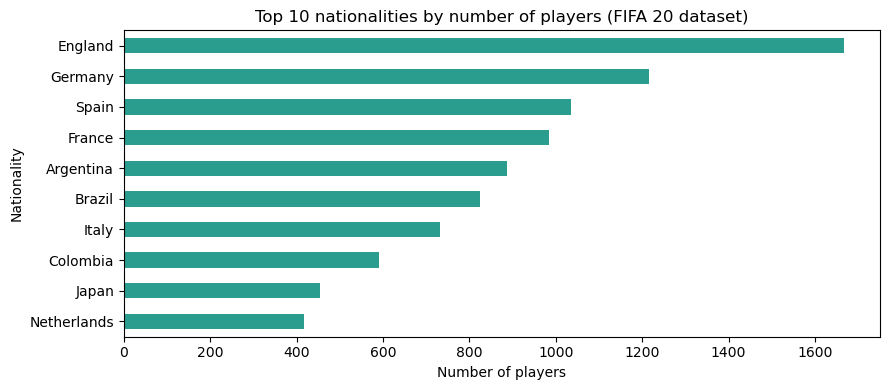

In [10]:
# Task 3.1: Top 10 countries with most players
import pandas as pd
import matplotlib.pyplot as plt

country_counts = players_clean_df['nationality'].value_counts().head(10)
print(country_counts)

plt.figure(figsize=(9,4))
country_counts.sort_values().plot(kind='barh', color='#2a9d8f')
plt.title('Top 10 nationalities by number of players (FIFA 20 dataset)')
plt.xlabel('Number of players')
plt.ylabel('Nationality')
plt.tight_layout()
plt.show()

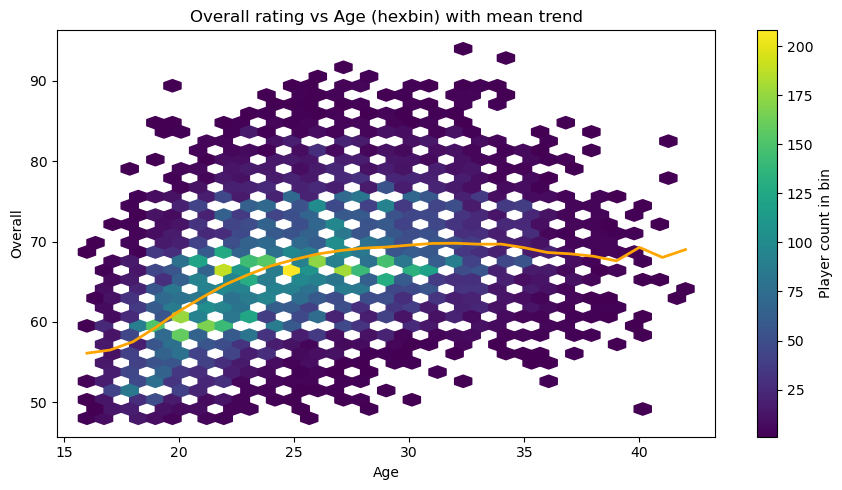

32
69.78927890610687
   age    overall  overall_smooth     delta
0   16  56.416667       56.101346       NaN
1   17  55.786026       56.492043  0.390697
2   18  57.273438       57.522294  1.030251
3   19  59.507418       59.334330  1.812036
4   20  61.222133       61.330699  1.996369
    age    overall  overall_smooth     delta
22   38  69.452381       68.172399 -0.298346
23   39  67.250000       67.593101 -0.579297
24   40  66.076923       69.275641  1.682540
25   41  74.500000       68.025641 -1.250000
26   42  63.500000       69.000000  0.974359


In [11]:
# Task 3.2: Overall rating vs age distribution + smoothed trend
import numpy as np
import matplotlib.pyplot as plt

plot_df = players_clean_df[['age','overall']].dropna().copy()
plot_df = plot_df[(plot_df['age']>=15) & (plot_df['age']<=45)]

# Mean overall by age and a simple smoothing via rolling window
mean_by_age = plot_df.groupby('age', as_index=False)['overall'].mean().sort_values('age')
mean_by_age['overall_smooth'] = mean_by_age['overall'].rolling(window=3, center=True, min_periods=1).mean()

plt.figure(figsize=(9,5))
plt.hexbin(plot_df['age'], plot_df['overall'], gridsize=35, cmap='viridis', mincnt=1)
cb = plt.colorbar()
cb.set_label('Player count in bin')
plt.plot(mean_by_age['age'], mean_by_age['overall_smooth'], color='orange', linewidth=2)
plt.title('Overall rating vs Age (hexbin) with mean trend')
plt.xlabel('Age')
plt.ylabel('Overall')
plt.tight_layout()
plt.show()

# Estimate "stop improving" age as the age at which the smoothed mean peaks
peak_idx = mean_by_age['overall_smooth'].idxmax()
peak_age = int(mean_by_age.loc[peak_idx, 'age'])
peak_overall = float(mean_by_age.loc[peak_idx, 'overall_smooth'])
print(peak_age)
print(peak_overall)

# Also show delta around peak to see plateau
mean_by_age['delta'] = mean_by_age['overall_smooth'].diff()
print(mean_by_age.head())
print(mean_by_age.tail())

                  count  median          mean     max
primary_position                                     
LW                  375  4000.0  14149.333333  470000
RW                  367  4000.0  15934.604905  565000
ST                 2552  4000.0  10271.943574  405000


C:\Users\asus\AppData\Local\Temp\ipykernel_12052\209206920.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([wage_off.loc[wage_off['primary_position']==p,'wage_eur'] for p in order_vals], labels=order_vals, showfliers=False)


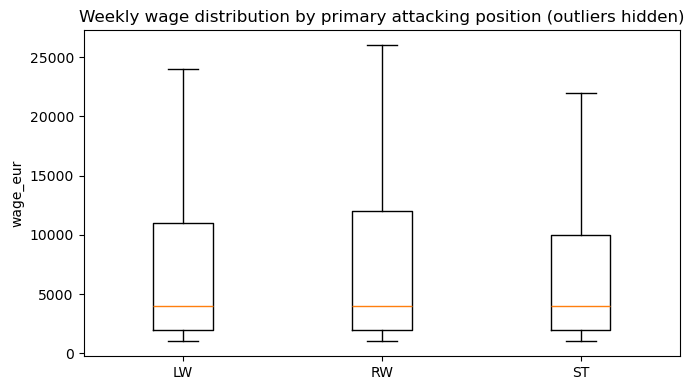

ST
           short_name               club  overall  age  wage_eur
1   Cristiano Ronaldo           Juventus       93   34    405000
19          L. Suárez       FC Barcelona       89   32    355000
17          S. Agüero    Manchester City       89   31    300000
20     R. Lewandowski  FC Bayern München       89   30    235000
12            H. Kane  Tottenham Hotspur       89   25    220000
RW
         short_name             club  overall  age  wage_eur
0          L. Messi     FC Barcelona       94   32    565000
26      R. Sterling  Manchester City       88   24    255000
100         G. Bale      Real Madrid       85   29    250000
9          M. Salah        Liverpool       90   27    240000
41   Bernardo Silva  Manchester City       87   24    210000
LW
        short_name                 club  overall  age  wage_eur
4        E. Hazard          Real Madrid       91   28    470000
2        Neymar Jr  Paris Saint-Germain       92   27    290000
39         S. Mané            Liverpool    

In [12]:
# Task 3.3: Who gets paid most among ST vs RW vs LW (using primary_position)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

wage_df = players_clean_df[['short_name','primary_position','wage_eur','overall','age','club']].dropna().copy()

off_positions = ['ST','RW','LW']
wage_off = wage_df[wage_df['primary_position'].isin(off_positions)].copy()

# Remove zero wages (free agents / missing entries coded as 0)
wage_off = wage_off[wage_off['wage_eur'] > 0].copy()

summary = wage_off.groupby('primary_position')['wage_eur'].agg(['count','median','mean','max']).sort_values('median', ascending=False)
print(summary)

plt.figure(figsize=(7,4))
order_vals = summary.index.tolist()
plt.boxplot([wage_off.loc[wage_off['primary_position']==p,'wage_eur'] for p in order_vals], labels=order_vals, showfliers=False)
plt.title('Weekly wage distribution by primary attacking position (outliers hidden)')
plt.ylabel('wage_eur')
plt.tight_layout()
plt.show()

# Show top earners per role for intuition
for pos in off_positions:
    top_pos = wage_off[wage_off['primary_position']==pos].sort_values('wage_eur', ascending=False).head(5)
    print(pos)
    print(top_pos[['short_name','club','overall','age','wage_eur']])

    k  silhouette
0   3    0.215439
1   4    0.183567
2   5    0.163674
3   6    0.161597
4   7    0.159745
5   8    0.148742
6   9    0.142874
7  10    0.137864
3


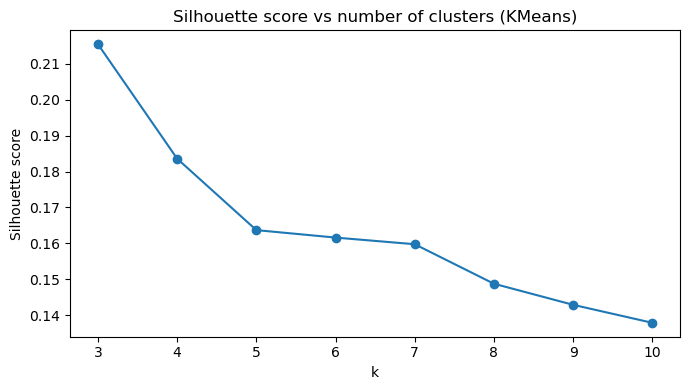

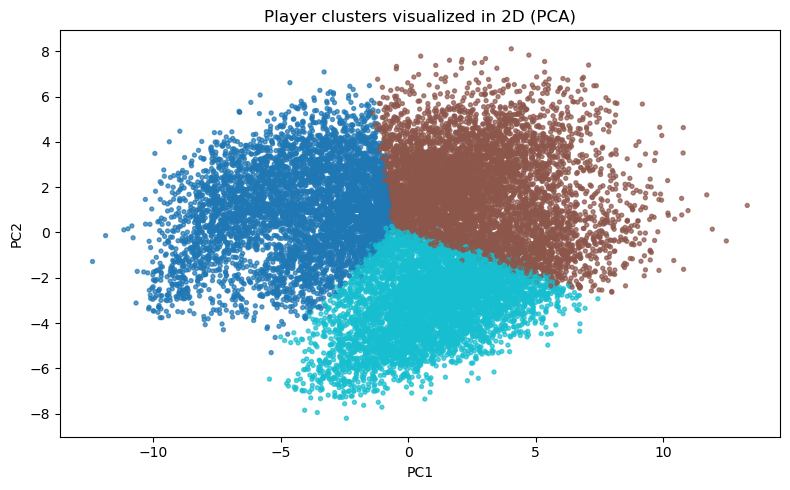

[0.40612429 0.22756514]
              pace   shooting    passing  dribbling  defending     physic  \
cluster                                                                     
0        60.815681  36.022401  48.695421  52.067597  61.843388  67.406760   
1        70.007251  60.769477  66.654300  69.893761  59.176728  69.222091   
2        71.790925  58.538771  54.857362  64.368371  32.872487  57.477886   

           overall  potential      wage_eur        age  
cluster                                                 
0        63.621340  69.907644   4893.495775  24.587738  
1        71.438954  74.232378  18755.817875  27.090556  
2        63.468888  70.663029   4432.892973  23.525751  
cluster  primary_position
0        CB                  2828
         RB                   636
         LB                   603
         CDM                  553
         CM                   323
1        CM                  1459
         CDM                  851
         LB                   657
       

In [14]:
# Task 2: Clustering outfield players by attributes
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X = outfield_df[skill_col_present].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Choose k via silhouette on a reasonable grid
k_vals = list(range(3, 11))
sil_scores = []
for k in k_vals:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

sil_df = pd.DataFrame({'k': k_vals, 'silhouette': sil_scores})
print(sil_df)

best_k = int(sil_df.sort_values('silhouette', ascending=False).iloc[0]['k'])
print(best_k)

plt.figure(figsize=(7,4))
plt.plot(sil_df['k'], sil_df['silhouette'], marker='o')
plt.title('Silhouette score vs number of clusters (KMeans)')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.tight_layout()
plt.show()

# Fit final model
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=20)
outfield_df['cluster'] = kmeans_final.fit_predict(X_scaled)

# PCA to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=outfield_df['cluster'], s=8, cmap='tab10', alpha=0.7)
plt.title('Player clusters visualized in 2D (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

print(pca.explained_variance_ratio_)

# Cluster profiles on core headline stats
profile_cols = ['pace','shooting','passing','dribbling','defending','physic']
profile_cols = [c for c in profile_cols if c in outfield_df.columns]
cluster_profiles = outfield_df.groupby('cluster')[profile_cols + ['overall','potential','wage_eur','age']].mean(numeric_only=True).sort_index()
print(cluster_profiles)

# Most common positions per cluster
pos_counts = outfield_df.groupby('cluster')['primary_position'].value_counts().groupby(level=0).head(5)
print(pos_counts)

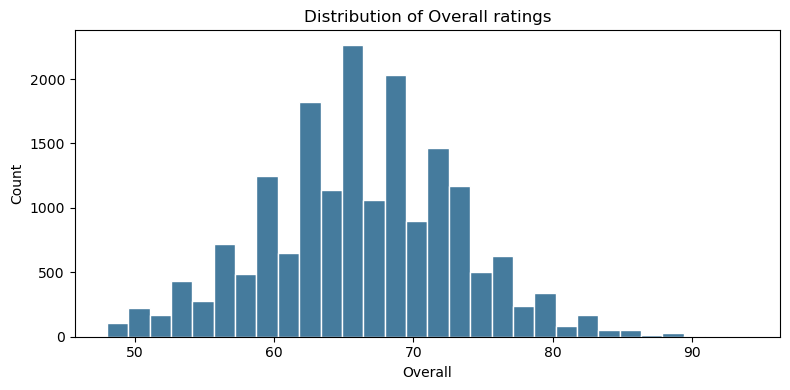

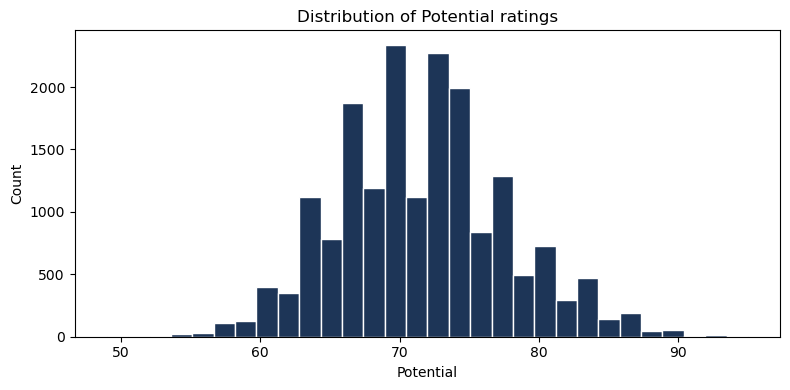

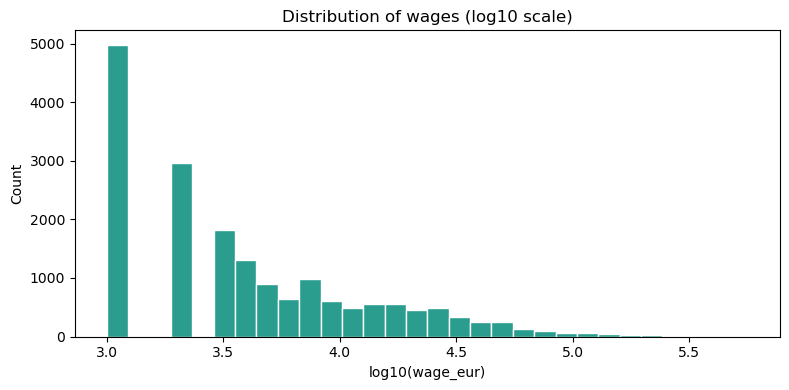

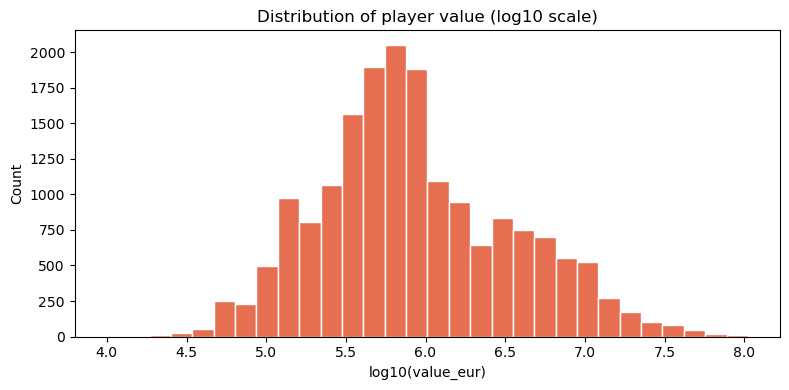

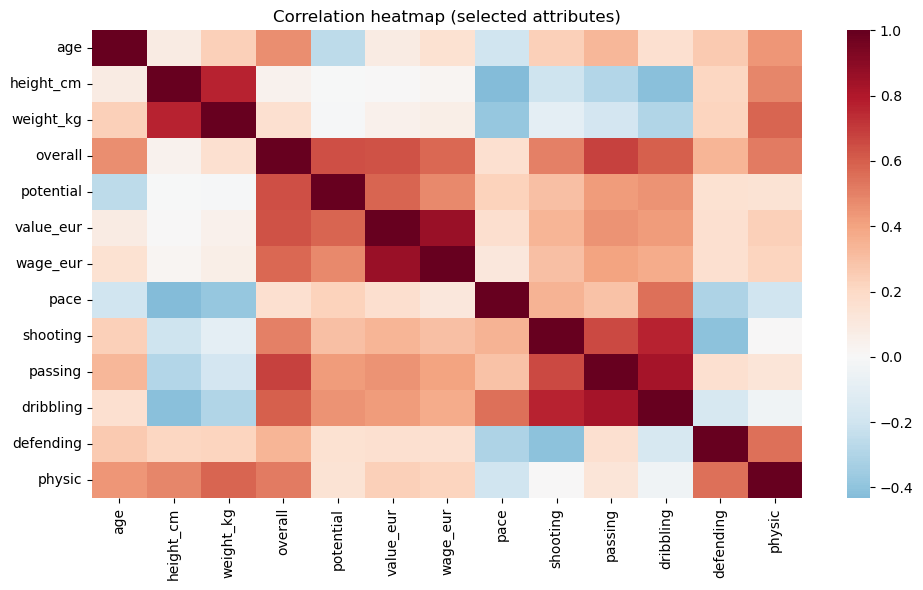

value_eur    0.858052
overall      0.573578
potential    0.475490
passing      0.403862
dribbling    0.371029
shooting     0.301760
physic       0.223157
defending    0.165624
age          0.151031
pace         0.113545
weight_kg    0.065946
height_cm    0.019547
Name: wage_eur, dtype: float64


In [16]:
# Task 1: A few key visuals for the report (overall, potential, wages, value) + correlation snapshot
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

viz_df = players_clean_df.copy()

plt.figure(figsize=(8,4))
plt.hist(viz_df['overall'].dropna(), bins=30, color='#457b9d', edgecolor='white')
plt.title('Distribution of Overall ratings')
plt.xlabel('Overall')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.hist(viz_df['potential'].dropna(), bins=30, color='#1d3557', edgecolor='white')
plt.title('Distribution of Potential ratings')
plt.xlabel('Potential')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Wage and value are heavy-tailed, show log10 histograms
wage_nonzero = viz_df.loc[viz_df['wage_eur']>0, 'wage_eur'].dropna()
value_nonzero = viz_df.loc[viz_df['value_eur']>0, 'value_eur'].dropna()

plt.figure(figsize=(8,4))
plt.hist(np.log10(wage_nonzero), bins=30, color='#2a9d8f', edgecolor='white')
plt.title('Distribution of wages (log10 scale)')
plt.xlabel('log10(wage_eur)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.hist(np.log10(value_nonzero), bins=30, color='#e76f51', edgecolor='white')
plt.title('Distribution of player value (log10 scale)')
plt.xlabel('log10(value_eur)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Correlation heatmap on a compact set
corr_cols = ['age','height_cm','weight_kg','overall','potential','value_eur','wage_eur',
             'pace','shooting','passing','dribbling','defending','physic']
corr_cols = [c for c in corr_cols if c in viz_df.columns]
corr_mat = viz_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr_mat, cmap='RdBu_r', center=0, annot=False)
plt.title('Correlation heatmap (selected attributes)')
plt.tight_layout()
plt.show()

# Show top correlations with wage (absolute)
wage_corr = corr_mat['wage_eur'].drop('wage_eur').sort_values(key=lambda s: s.abs(), ascending=False)
print(wage_corr.head(12))